<a href="https://colab.research.google.com/github/nehansa2003/Weather-Forecasting-Project/blob/main/Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
from google.colab import drive
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display




In [17]:
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
dataset='/content/drive/MyDrive/Capstone_Datasets/weather_data_processed_2020_2025.parquet'

In [19]:
# Load Parquet dataset
weather_df = pd.read_parquet(
    dataset,
    engine="pyarrow"
)

print("Dataset loaded successfully!")

print("\nShape:")
print(weather_df.shape)

print("\nColumns:")
print(weather_df.columns.tolist())

print("\nDate range:")
print(weather_df["datetime"].min())
print("to")
print(weather_df["datetime"].max())

print("\nDistricts:")
print(weather_df["district"].unique())

print("\nGeographical points:")
print(weather_df["global_pointid"].nunique())

display(weather_df.head())

Dataset loaded successfully!

Shape:
(5629056, 34)

Columns:
['district', 'pointid', 'global_pointid', 'latitude', 'longitude', 'elevation_m', 'datetime', 'date', 'day', 'month', 'year', 'time', 'season', 'hour', 'day_of_week', 'day_of_year', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'temperature_c', 'feelslike_c', 'humidity_pct', 'dewpoint_c', 'pressure_hpa', 'windspeed_kmh', 'winddirection_deg', 'winddirection_compass', 'windgust_kmh', 'rainfall_mm', 'cloudcover_pct', 'solarradiation_wm2', 'sunshineduration_s']

Date range:
2020-01-01 00:00:00
to
2025-12-31 23:00:00

Districts:
['Colombo' 'Galle' 'Gampaha' 'Jaffna' 'Kandy']

Geographical points:
107


,district,pointid,global_pointid,latitude,longitude,elevation_m,datetime,date,day,month,...,dewpoint_c,pressure_hpa,windspeed_kmh,winddirection_deg,winddirection_compass,windgust_kmh,rainfall_mm,cloudcover_pct,solarradiation_wm2,sunshineduration_s
0,Colombo,1,COL_001,6.85991,79.79351,0.0,2020-01-01 00:00:00,2020-01-01,1,1,...,24.0,1012.2,9.0,157,SSE,22.0,0.1,43,0.0,0.0
1,Colombo,1,COL_001,6.85991,79.79351,0.0,2020-01-01 01:00:00,2020-01-01,1,1,...,23.9,1011.7,5.5,148,SSE,15.8,0.0,50,0.0,0.0
2,Colombo,1,COL_001,6.85991,79.79351,0.0,2020-01-01 02:00:00,2020-01-01,1,1,...,24.0,1011.1,4.3,156,SSE,9.7,0.1,78,0.0,0.0
3,Colombo,1,COL_001,6.85991,79.79351,0.0,2020-01-01 03:00:00,2020-01-01,1,1,...,23.9,1010.4,3.9,146,SE,8.6,0.1,92,0.0,0.0
4,Colombo,1,COL_001,6.85991,79.79351,0.0,2020-01-01 04:00:00,2020-01-01,1,1,...,23.8,1010.5,3.6,96,E,7.2,0.0,90,0.0,0.0


Variable Information

In [20]:
variable_info = pd.DataFrame({
    "Column": weather_df.columns,
    "Data_Type": weather_df.dtypes.astype(str),
    "Non_Null_Count": weather_df.notna().sum().values,
    "Missing_Count": weather_df.isna().sum().values,
    "Missing_Percentage": (
        weather_df.isna().mean().values * 100
    ),
    "Unique_Values": weather_df.nunique().values
})

display(variable_info)

,Column,Data_Type,Non_Null_Count,Missing_Count,Missing_Percentage,Unique_Values
district,district,object,5629056,0,0.0,5
pointid,pointid,int64,5629056,0,0.0,33
global_pointid,global_pointid,object,5629056,0,0.0,107
latitude,latitude,float64,5629056,0,0.0,27
longitude,longitude,float64,5629056,0,0.0,29
elevation_m,elevation_m,float64,5629056,0,0.0,66
datetime,datetime,datetime64[ns],5629056,0,0.0,52608
date,date,object,5629056,0,0.0,2192
day,day,int64,5629056,0,0.0,31
month,month,int64,5629056,0,0.0,12


Descriptive statistics

In [21]:
numeric_columns = weather_df.select_dtypes(
    include=np.number
).columns

descriptive_stats = (
    weather_df[numeric_columns]
    .describe()
    .T
)

descriptive_stats["missing"] = (
    weather_df[numeric_columns]
    .isna()
    .sum()
)

display(descriptive_stats)

,count,mean,std,min,25%,50%,75%,max,missing
pointid,5629056.0,1.278505e+01,8.466568,1.00000,6.000000,1.100000e+01,18.000000,33.00000,0
latitude,5629056.0,7.263026e+00,1.155496,5.84691,6.191230,7.130690e+00,7.386550,9.75914,0
longitude,5629056.0,8.024512e+01,0.296227,79.72583,79.996570,8.015175e+01,80.536970,80.79491,0
elevation_m,5629056.0,2.081963e+02,330.875121,0.00000,1.000000,2.400000e+01,427.000000,1565.00000,0
day,5629056.0,1.573266e+01,8.801371,1.00000,8.000000,1.600000e+01,23.000000,31.00000,0
month,5629056.0,6.521898e+00,3.448987,1.00000,4.000000,7.000000e+00,10.000000,12.00000,0
year,5629056.0,2.022500e+03,1.708181,2020.00000,2021.000000,2.022500e+03,2024.000000,2025.00000,0
hour,5629056.0,1.150000e+01,6.922187,0.00000,5.750000,1.150000e+01,17.250000,23.00000,0
day_of_week,5629056.0,2.999544e+00,1.999658,0.00000,1.000000,3.000000e+00,5.000000,6.00000,0
day_of_year,5629056.0,1.831670e+02,105.462791,1.00000,92.000000,1.830000e+02,274.250000,366.00000,0


District-level dataset distribution

In [22]:
district_records = (
    weather_df
    .groupby("district")
    .size()
    .sort_values(ascending=False)
)

display(
    district_records.to_frame("Record_Count")
)

,Record_Count
district,
Kandy,1736064
Galle,1525632
Gampaha,894336
Jaffna,894336
Colombo,578688


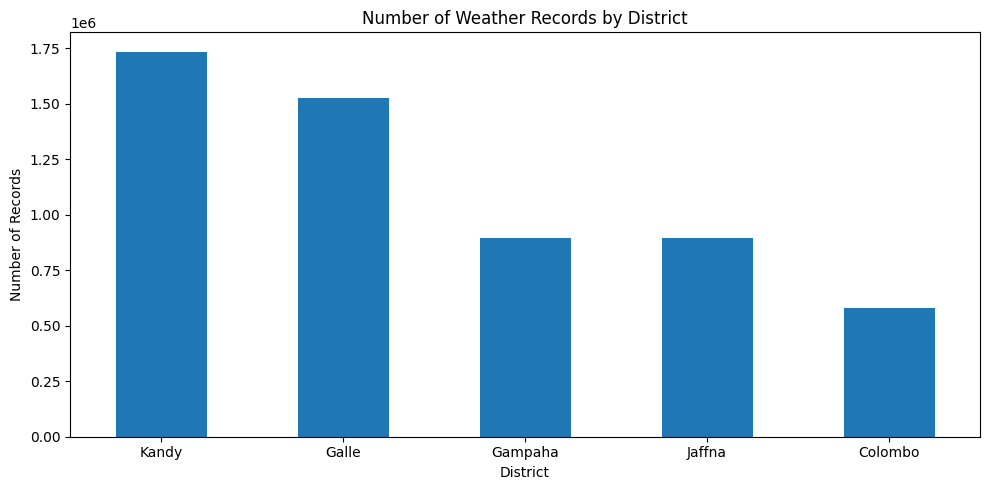

In [23]:
plt.figure(figsize=(10, 5))

district_records.plot(kind="bar")

plt.title("Number of Weather Records by District")
plt.xlabel("District")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Geographical point distribution

In [24]:
point_counts = (
    weather_df
    .groupby("district")["global_pointid"]
    .nunique()
)

display(
    point_counts.to_frame("Number_of_Points")
)

,Number_of_Points
district,
Colombo,11
Galle,29
Gampaha,17
Jaffna,17
Kandy,33


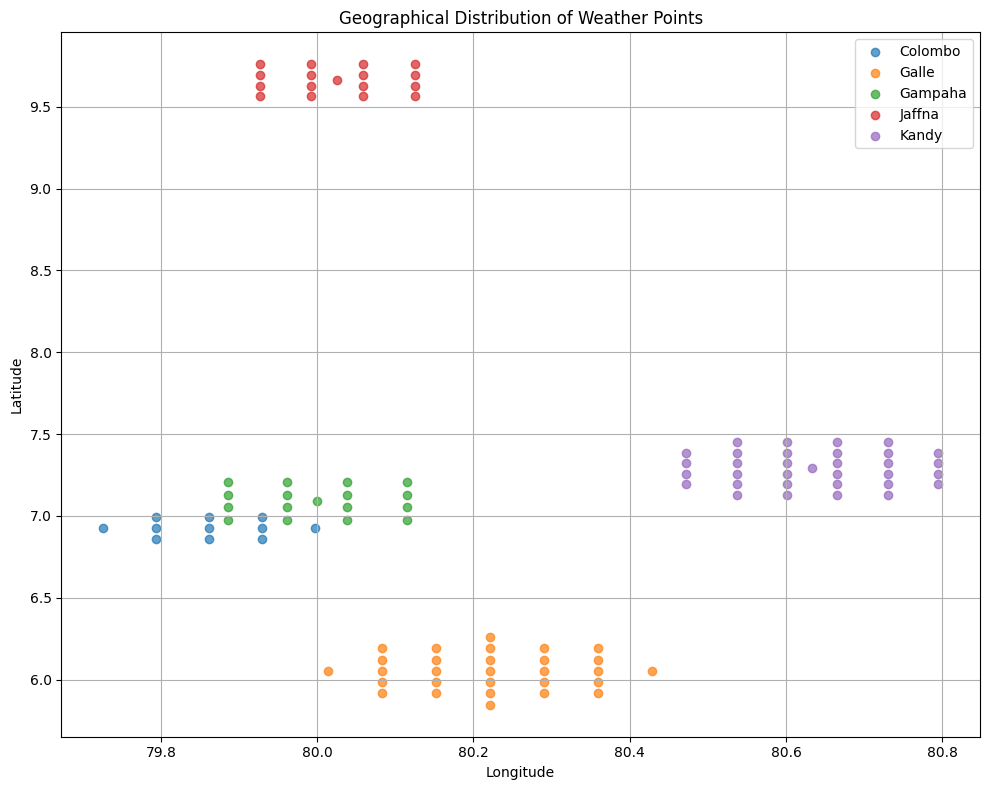

In [25]:
plt.figure(figsize=(10, 8))

for district in weather_df["district"].unique():

    subset = weather_df[
        weather_df["district"] == district
    ].drop_duplicates("global_pointid")

    plt.scatter(
        subset["longitude"],
        subset["latitude"],
        label=district,
        alpha=0.7
    )

plt.title("Geographical Distribution of Weather Points")

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.legend()

plt.grid(True)

plt.tight_layout()
plt.show()

Verify hourly frequency

In [ ]:
time_differences = (
    weather_df
    .sort_values(
        ["global_pointid", "datetime"]
    )
    .groupby("global_pointid")["datetime"]
    .diff()
)

print("Time difference distribution:")

display(
    time_differences
    .value_counts()
    .head(10)
)

Identify missing hourly observations

In [ ]:
sorted_df = weather_df.sort_values(
    ["global_pointid", "datetime"]
)

time_diff = (
    sorted_df
    .groupby("global_pointid")["datetime"]
    .diff()
)

missing_intervals = (
    time_diff[
        time_diff > pd.Timedelta(hours=1)
    ]
)

print(
    "Number of gaps greater than 1 hour:",
    len(missing_intervals)
)

Largest temporal gaps

In [ ]:
gap_info = sorted_df.copy()

gap_info["time_gap"] = (
    gap_info
    .groupby("global_pointid")["datetime"]
    .diff()
)

largest_gaps = (
    gap_info[
        gap_info["time_gap"] > pd.Timedelta(hours=1)
    ]
    [
        [
            "district",
            "global_pointid",
            "datetime",
            "time_gap"
        ]
    ]
    .sort_values(
        "time_gap",
        ascending=False
    )
)

display(
    largest_gaps.head(20)
)

Elevation analysis

In [ ]:
elevation_summary = (
    point_locations
    .groupby("district")["elevation_m"]
    .agg(
        mean="mean",
        minimum="min",
        maximum="max"
    )
)

display(elevation_summary)

Weather variable distributions

In [ ]:
weather_variables = [
    "temperature_c",
    "feelslike_c",
    "humidity_pct",
    "dewpoint_c",
    "pressure_hpa",
    "windspeed_kmh",
    "windgust_kmh",
    "rainfall_mm",
    "cloudcover_pct",
    "solarradiation_wm2",
    "sunshineduration_s"
]

for column in weather_variables:

    if column not in weather_df.columns:
        continue

    plt.figure(figsize=(9, 5))

    plt.hist(
        weather_df[column].dropna(),
        bins=50
    )

    plt.title(
        f"Distribution of {column}"
    )

    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

Rainfall occurrence

In [ ]:
rain_count = pd.Series(
    np.where(
        weather_df["rainfall_mm"] > 0,
        "Rain",
        "No Rain"
    )
).value_counts()

display(
    rain_count.to_frame(
        "Count"
    )
)

#Percentage
rain_percentage = (
    rain_count /
    rain_count.sum()
    * 100
)

display(
    rain_percentage.to_frame(
        "Percentage"
    )
)

Rainfall distribution

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(
    weather_df["rainfall_mm"].dropna(),
    bins=50
)

plt.title(
    "Distribution of Hourly Rainfall"
)

plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:
rainy_hours = weather_df[
    weather_df["rainfall_mm"] > 0
]

plt.figure(figsize=(10, 5))

plt.hist(
    rainy_hours["rainfall_mm"],
    bins=50
)

plt.title(
    "Rainfall Distribution During Rainy Hours"
)

plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Hourly weather patterns

In [ ]:
hourly_summary = (
    weather_df
    .groupby("hour")
    [
        [
            "temperature_c",
            "humidity_pct",
            "pressure_hpa",
            "windspeed_kmh",
            "rainfall_mm",
            "cloudcover_pct",
            "solarradiation_wm2"
        ]
    ]
    .mean()
)

display(hourly_summary)

Hourly temperature

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_summary.index,
    hourly_summary["temperature_c"],
    marker="o"
)

plt.title(
    "Average Temperature by Hour"
)

plt.xlabel("Hour")
plt.ylabel("Temperature (°C)")

plt.xticks(range(24))
plt.grid(True)

plt.tight_layout()
plt.show()

Hourly humidity

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_summary.index,
    hourly_summary["humidity_pct"],
    marker="o"
)

plt.title(
    "Average Humidity by Hour"
)

plt.xlabel("Hour")
plt.ylabel("Humidity (%)")

plt.xticks(range(24))
plt.grid(True)

plt.tight_layout()
plt.show()

Hourly rainfall

In [ ]:
hourly_rainfall = (
    weather_df
    .groupby("hour")["rainfall_mm"]
    .agg(
        mean="mean",
        median="median",
        maximum="max",
        rain_probability=lambda x: (
            x > 0
        ).mean() * 100
    )
)

display(hourly_rainfall)

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_rainfall.index,
    hourly_rainfall["rain_probability"],
    marker="o"
)

plt.title(
    "Rainfall Probability by Hour"
)

plt.xlabel("Hour")
plt.ylabel("Rain Probability (%)")

plt.xticks(range(24))
plt.grid(True)

plt.tight_layout()
plt.show()

Monthly weather patterns

In [ ]:
monthly_summary = (
    weather_df
    .groupby("month")
    [
        [
            "temperature_c",
            "humidity_pct",
            "pressure_hpa",
            "windspeed_kmh",
            "rainfall_mm",
            "cloudcover_pct",
            "solarradiation_wm2"
        ]
    ]
    .mean()
)

display(monthly_summary)

Monthly rainfall

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_summary.index,
    monthly_summary["rainfall_mm"],
    marker="o"
)

plt.title(
    "Average Rainfall by Month"
)

plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")

plt.xticks(range(1, 13))
plt.grid(True)

plt.tight_layout()
plt.show()

Seasonal analysis

In [ ]:
seasonal_summary = (
    weather_df
    .groupby("season")
    [
        [
            "temperature_c",
            "humidity_pct",
            "pressure_hpa",
            "windspeed_kmh",
            "rainfall_mm",
            "cloudcover_pct"
        ]
    ]
    .mean()
)

display(seasonal_summary)

Yearly rainfall trends

In [ ]:
yearly_rainfall = (
    weather_df
    .groupby("year")["rainfall_mm"]
    .agg(
        mean="mean",
        median="median",
        maximum="max"
    )
)

display(yearly_rainfall)

District weather comparison

In [ ]:
district_weather = (
    weather_df
    .groupby("district")
    [
        [
            "temperature_c",
            "humidity_pct",
            "pressure_hpa",
            "windspeed_kmh",
            "rainfall_mm",
            "cloudcover_pct",
            "solarradiation_wm2"
        ]
    ]
    .mean()
)

display(district_weather)

District rainfall comparison

In [ ]:
district_rainfall = (
    weather_df
    .groupby("district")["rainfall_mm"]
    .agg(
        mean="mean",
        median="median",
        maximum="max",
        rain_probability=lambda x: (
            x > 0
        ).mean() * 100
    )
)

display(district_rainfall)

Point-level rainfall variation

In [ ]:
point_rainfall = (
    weather_df
    .groupby(
        [
            "district",
            "global_pointid"
        ]
    )["rainfall_mm"]
    .agg(
        mean="mean",
        median="median",
        maximum="max",
        rain_probability=lambda x: (
            x > 0
        ).mean() * 100
    )
    .reset_index()
)

display(
    point_rainfall.head(20)
)

Point-level temperature variation

In [ ]:
point_temperature = (
    weather_df
    .groupby(
        [
            "district",
            "global_pointid"
        ]
    )["temperature_c"]
    .agg(
        mean="mean",
        minimum="min",
        maximum="max"
    )
    .reset_index()
)

display(
    point_temperature.head(20)
)

Spatial rainfall similarity

In [ ]:
rainfall_point_matrix = (
    weather_df
    .pivot_table(
        index="datetime",
        columns="global_pointid",
        values="rainfall_mm"
    )
)

print(
    "Rainfall point matrix shape:",
    rainfall_point_matrix.shape
)

display(
    rainfall_point_matrix.head()
)

Spatial rainfall correlation

In [ ]:
rainfall_point_correlation = (
    rainfall_point_matrix
    .corr()
)

display(
    rainfall_point_correlation.iloc[:10, :10]
)

Create geographical distance matrix

In [ ]:
def haversine_distance(
    lat1,
    lon1,
    lat2,
    lon2
):
    """
    Calculate distance between two geographic
    coordinates in kilometres.
    """

    R = 6371.0

    lat1 = np.radians(lat1)
    lat2 = np.radians(lat2)

    dlat = lat2 - lat1

    dlon = np.radians(
        lon2 - lon1
    )

    a = (
        np.sin(dlat / 2) ** 2
        +
        np.cos(lat1)
        *
        np.cos(lat2)
        *
        np.sin(dlon / 2) ** 2
    )

    c = (
        2 *
        np.arctan2(
            np.sqrt(a),
            np.sqrt(1 - a)
        )
    )

    return R * c

Calculate point distances

In [ ]:
point_locations = (
    weather_df[
        [
            "global_pointid",
            "district",
            "latitude",
            "longitude"
        ]
    ]
    .drop_duplicates(
        "global_pointid"
    )
    .reset_index(drop=True)
)

distance_records = []

for i in range(
    len(point_locations)
):

    for j in range(
        i + 1,
        len(point_locations)
    ):

        p1 = point_locations.iloc[i]
        p2 = point_locations.iloc[j]

        distance = haversine_distance(
            p1["latitude"],
            p1["longitude"],
            p2["latitude"],
            p2["longitude"]
        )

        distance_records.append({

            "point1":
                p1["global_pointid"],

            "point2":
                p2["global_pointid"],

            "district1":
                p1["district"],

            "district2":
                p2["district"],

            "distance_km":
                distance
        })

distance_df = pd.DataFrame(
    distance_records
)

display(
    distance_df.head()
)

Spatial similarity vs distance

In [ ]:
records = []

for _, row in distance_df.iterrows():

    p1 = row["point1"]
    p2 = row["point2"]

    if (
        p1 in rainfall_point_correlation.columns
        and
        p2 in rainfall_point_correlation.columns
    ):

        correlation = (
            rainfall_point_correlation
            .loc[p1, p2]
        )

        records.append({

            "point1":
                p1,

            "point2":
                p2,

            "distance_km":
                row["distance_km"],

            "rainfall_correlation":
                correlation
        })

spatial_similarity = pd.DataFrame(
    records
)

display(
    spatial_similarity.head()
)

In [ ]:
plt.figure(figsize=(9, 6))

plt.scatter(
    spatial_similarity["distance_km"],
    spatial_similarity["rainfall_correlation"],
    alpha=0.4
)

plt.title(
    "Geographical Distance vs Rainfall Similarity"
)

plt.xlabel(
    "Distance Between Points (km)"
)

plt.ylabel(
    "Rainfall Correlation"
)

plt.grid(True)

plt.tight_layout()
plt.show()

Temporal dependency: rainfall autocorrelation

In [ ]:
lags = [
    1,
    2,
    3,
    6,
    12,
    24
]

autocorrelation_results = []

for lag in lags:

    correlations = []

    for point_id, group in weather_df.groupby(
        "global_pointid"
    ):

        series = (
            group
            .sort_values("datetime")
            ["rainfall_mm"]
        )

        correlation = (
            series
            .autocorr(lag=lag)
        )

        correlations.append(
            correlation
        )

    autocorrelation_results.append({

        "lag_hours":
            lag,

        "mean_autocorrelation":
            np.nanmean(
                correlations
            )
    })

autocorrelation_df = pd.DataFrame(
    autocorrelation_results
)

display(
    autocorrelation_df
)

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    autocorrelation_df["lag_hours"],
    autocorrelation_df["mean_autocorrelation"],
    marker="o"
)

plt.title(
    "Rainfall Temporal Autocorrelation"
)

plt.xlabel("Lag (hours)")
plt.ylabel("Mean Autocorrelation")

plt.xticks(lags)
plt.grid(True)

plt.tight_layout()
plt.show()

Temporal dependency of other variables

In [ ]:
variables_for_autocorrelation = [
    "temperature_c",
    "humidity_pct",
    "pressure_hpa",
    "windspeed_kmh",
    "rainfall_mm",
    "cloudcover_pct"
]

lag_values = [
    1,
    3,
    6,
    12,
    24
]

autocorrelation_summary = []

for variable in variables_for_autocorrelation:

    for lag in lag_values:

        correlations = []

        for point_id, group in weather_df.groupby(
            "global_pointid"
        ):

            series = (
                group
                .sort_values("datetime")
                [variable]
            )

            correlations.append(
                series.autocorr(
                    lag=lag
                )
            )

        autocorrelation_summary.append({

            "variable":
                variable,

            "lag_hours":
                lag,

            "mean_autocorrelation":
                np.nanmean(
                    correlations
                )
        })

autocorrelation_summary = pd.DataFrame(
    autocorrelation_summary
)

display(
    autocorrelation_summary
)

Correlation between weather variables

In [ ]:
correlation_variables = [
    "temperature_c",
    "feelslike_c",
    "humidity_pct",
    "dewpoint_c",
    "pressure_hpa",
    "windspeed_kmh",
    "winddirection_deg",
    "windgust_kmh",
    "rainfall_mm",
    "cloudcover_pct",
    "solarradiation_wm2",
    "sunshineduration_s"
]

correlation_variables = [
    col for col in correlation_variables
    if col in weather_df.columns
]

correlation_matrix = (
    weather_df[
        correlation_variables
    ]
    .corr()
)

display(
    correlation_matrix
)

Correlations specifically with rainfall

In [ ]:
rainfall_correlations = (
    correlation_matrix[
        "rainfall_mm"
    ]
    .drop("rainfall_mm")
    .sort_values(
        key=abs,
        ascending=False
    )
)

display(
    rainfall_correlations.to_frame(
        "Correlation_with_Rainfall"
    )
)

Short-term forecastability-We want to investigate whether weather at time t has a relationship with rainfall at:

In [ ]:
forecast_df = (
    weather_df
    .sort_values(
        [
            "global_pointid",
            "datetime"
        ]
    )
    .copy()
)

for horizon in [1, 2, 3]:

    forecast_df[
        f"rainfall_t_plus_{horizon}"
    ] = (
        forecast_df
        .groupby(
            "global_pointid"
        )["rainfall_mm"]
        .shift(-horizon)
    )

display(
    forecast_df[
        [
            "global_pointid",
            "datetime",
            "rainfall_mm",
            "rainfall_t_plus_1",
            "rainfall_t_plus_2",
            "rainfall_t_plus_3"
        ]
    ].head(20)
)

Current rainfall vs future rainfall

In [ ]:
future_correlations = {}

for horizon in [1, 2, 3]:

    future_correlations[
        f"t+{horizon}"
    ] = (
        forecast_df[
            [
                "rainfall_mm",
                f"rainfall_t_plus_{horizon}"
            ]
        ]
        .corr()
        .iloc[0, 1]
    )

future_correlation_df = pd.DataFrame(
    {
        "Forecast_Horizon":
            list(future_correlations.keys()),

        "Correlation":
            list(future_correlations.values())
    }
)

display(
    future_correlation_df
)

Rainfall persistence

In [ ]:
rain_persistence = []

for horizon in [1, 2, 3]:

    current_rain = (
        forecast_df["rainfall_mm"] > 0
    )

    future_rain = (
        forecast_df[
            f"rainfall_t_plus_{horizon}"
        ] > 0
    )

    valid = (
        current_rain
        &
        forecast_df[
            f"rainfall_t_plus_{horizon}"
        ].notna()
    )

    probability = (
        future_rain[valid]
        .groupby(
            current_rain[valid]
        )
        .mean()
    )

    rain_persistence.append({

        "Horizon":
            f"{horizon} hour",

        "P(Rain future | No rain now)":
            probability.get(
                False,
                np.nan
            ),

        "P(Rain future | Rain now)":
            probability.get(
                True,
                np.nan
            )
    })

rain_persistence_df = pd.DataFrame(
    rain_persistence
)

display(
    rain_persistence_df
)

Future rainfall relationship with current weather

In [ ]:
predictor_variables = [
    "temperature_c",
    "humidity_pct",
    "dewpoint_c",
    "pressure_hpa",
    "windspeed_kmh",
    "windgust_kmh",
    "cloudcover_pct",
    "solarradiation_wm2",
    "rainfall_mm"
]

forecast_relationships = []

for horizon in [1, 2, 3]:

    target = (
        f"rainfall_t_plus_{horizon}"
    )

    for variable in predictor_variables:

        correlation = (
            forecast_df[
                [
                    variable,
                    target
                ]
            ]
            .corr()
            .iloc[0, 1]
        )

        forecast_relationships.append({

            "Horizon":
                f"t+{horizon}",

            "Variable":
                variable,

            "Correlation":
                correlation
        })

forecast_relationships_df = pd.DataFrame(
    forecast_relationships
)

display(
    forecast_relationships_df
)

Extreme rainfall

In [ ]:
rainfall_quantiles = (
    weather_df[
        "rainfall_mm"
    ]
    .quantile(
        [0.90, 0.95, 0.99]
    )
)

display(
    rainfall_quantiles.to_frame(
        "Rainfall_mm"
    )
)

In [ ]:
extreme_threshold = (
    rainfall_quantiles.loc[0.99]
)

extreme_rainfall = weather_df[
    weather_df["rainfall_mm"]
    >= extreme_threshold
]

print(
    "Extreme rainfall threshold:",
    extreme_threshold,
    "mm"
)

print(
    "Number of extreme observations:",
    len(extreme_rainfall)
)

display(
    extreme_rainfall[
        [
            "district",
            "global_pointid",
            "datetime",
            "rainfall_mm",
            "temperature_c",
            "humidity_pct",
            "pressure_hpa",
            "windspeed_kmh",
            "cloudcover_pct"
        ]
    ]
    .sort_values(
        "rainfall_mm",
        ascending=False
    )
    .head(20)
)

Check data suitability for LSTM/GRU

In [ ]:
point_sequence_summary = (
    weather_df
    .groupby(
        [
            "district",
            "global_pointid"
        ]
    )
    .agg(
        observations=(
            "datetime",
            "count"
        ),

        start_time=(
            "datetime",
            "min"
        ),

        end_time=(
            "datetime",
            "max"
        ),

        missing_rainfall=(
            "rainfall_mm",
            lambda x: x.isna().sum()
        )
    )
    .reset_index()
)

display(
    point_sequence_summary.head(20)
)

Save EDA outputs

In [ ]:
EDA_DIR = (
    "/content/drive/MyDrive/"
    "Capstone_Datasets/"
    "EDA_Results"
)

import os

os.makedirs(
    EDA_DIR,
    exist_ok=True
)

district_weather.to_csv(
    os.path.join(
        EDA_DIR,
        "district_weather_summary.csv"
    )
)

district_rainfall.to_csv(
    os.path.join(
        EDA_DIR,
        "district_rainfall_summary.csv"
    )
)

point_rainfall.to_csv(
    os.path.join(
        EDA_DIR,
        "point_rainfall_summary.csv"
    ),
    index=False
)

spatial_similarity.to_csv(
    os.path.join(
        EDA_DIR,
        "spatial_rainfall_similarity.csv"
    ),
    index=False
)

autocorrelation_summary.to_csv(
    os.path.join(
        EDA_DIR,
        "temporal_autocorrelation.csv"
    ),
    index=False
)

future_correlation_df.to_csv(
    os.path.join(
        EDA_DIR,
        "future_rainfall_correlation.csv"
    ),
    index=False
)

rain_persistence_df.to_csv(
    os.path.join(
        EDA_DIR,
        "rainfall_persistence.csv"
    ),
    index=False
)

forecast_relationships_df.to_csv(
    os.path.join(
        EDA_DIR,
        "forecast_relationships.csv"
    ),
    index=False
)

print("EDA results saved successfully.")
print(EDA_DIR)